# Transformando Problemas Reais em Soluções Quânticas
O principal objetivo é converter o problema clássico do **Travalling Salesman Problem (TSP)**, também conhecido como *caixeiro viajante*, em um algoritmo quântico. Para isso, devem ser seguidos os passos:

1. Transformar o problema em QUBO;
2. Transformar o QUBO em Hamiltoniano;
3. Aplicar o Hamiltoniano em um algoritmo quântico.

Este notebook está organizado como segue: primeiramente, a transformação de um modelo simples QUBO em hamiltoniano é apresentado na *[Seção 1](#secao1)*. Em seguida, a *[Seção 2](#secao2)* aborda o problema clássico do TSP, bem como sua transformação para hamiltoniano. Na *[Seção 3](#secao3)*, o algoritmo quântico FALQON é definido e na *[Seção 4](#secao4)* o FALQON é aplicado para solucionar o TSP. Por fim, as principais conclusões deste trabalho são abordados na *[Seção 5](#secao5)*.

# [1 QUBO](#secao1)
Quadratic Unconstrained Binary Optimization (QUBO) é um problema de otimização que envolve a minimização de uma função quadrática de variáveis binárias.

Esse tipo de problema é comumente encontrado em diversas áreas, como ciência da computação, engenharia, matemática e física.

O objetivo do QUBO é encontrar a atribuição de valores binários para as variáveis que minimize a função quadrática.

Ele é amplamente aplicado tanto em computação clássica quanto em computação quântica, especialmente em processadores de recozimento quântico, como os da D-Wave.

Um problema QUBO busca minimizar a seguinte função quadrática:

$E(x) = \sum_{i} Q_{ii} x_i + \sum_{i < j} Q_{ij} x_i x_j$

Onde:
- $x_i \in \{0, 1\}$ : São variáveis binárias (ligado/desligado, escolha/não escolha).
- $Q$ : É uma matriz quadrada simétrica de coeficientes (pesos).
- $Q_{ii}$ : São os termos lineares (individuais).
- $Q_{ij}$ : São os termos quadráticos (interações entre variáveis).

O objetivo é encontrar o vetor $x = [x_1, x_2, \dots, x_n]$  que minimize a função $E(x)$.

## 1.1 Modelo Simples
Variáveis: $\vec{x} = (x_1, x_2, x_3)$, sendo $x_i$ 0 ou 1.

Problema quadrático: $Q(\vec{x}) = x_1 + 2x_1x_2 - 3x_2x_3 - 4x_1x_3 - 5$.

Modelagem do problema : $Q(\vec{x}) = \sum_{i,j=1}^3 d_{ij} x_i x_j + \sum_{i=1}^3 c_i x_i + c$.

**Exemplo:**

$Q(000) = -5$

$Q(001) = -5$

$Q(010) = -5$

$Q(011) = -8$

$Q(100) = -4$

$Q(101) = -8$

$Q(110) = -2$

$Q(111) = -9$

### 1.1.1 Transformando em Hamiltoniano
Objetivo: criar uma matriz para encontrar o autovetor associado à menor energia, ou seja, encontrar o estado fundamental.

**Exemplo**:

$ H = \begin{bmatrix}
-5 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & -5 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & -5 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & -8 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & -4 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & -8 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & -2 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & -9
\end{bmatrix}$

### 1.1.2 Convertendo a função quadrática em Hamiltoniano
Objetivo: $H = Ž_1 + 2Ž_1Ž_2 - 3 Ž_2Ž_3 - 4 Ž_1Ž_3 - 5$.

Ou seja, $Ž_k = (Ž_1, Ž_2, Ž_3)$.

Transformação de cada $Ž$ para hamiltoniano

$Ž_i = I(2^{i-1}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{n-i})$

Ou seja, considerando usar 6 qubits, temos:

$Ž_1 = I(2^{0}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{5})$

$Ž_2 = I(2^{1}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{4})$

$Ž_3 = I(2^{2}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{3})$

$Ž_4 = I(2^{3}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{2})$

$Ž_5 = I(2^{4}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{1})$

$Ž_6 = I(2^{5}) \otimes \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix} \otimes I(2^{0})$


Precisa-se mudar o valor da matriz para retornar valores binários (0 ou 1). Então, ao invés de usar $\sigma Z = \begin{bmatrix} 1 & 0 \\ 0 & -1  \end{bmatrix}$, será utilizado $Ž = \begin{bmatrix} \frac{1 - \sigma Z}{2} \end{bmatrix}$. Sendo assim, $Ž\ket{0}$ retorna $\ket{0}$ e $Ž\ket{1}$ retorna $1\ket{1}$.

#### Implementação

In [2]:
import numpy as np

n = 3  # variáveis

# matriz nula com n dimensões, sendo cada dimensão composta por uma matriz nxn
# receberá valores -1, 0, 1 na diagonal principal
z = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128 )

# mesmo princípio da matriz z 
# futuramente, aplicando (1 - PauliZ)/2, converterá os valores da matriz z acima para 0 e 1
# ela será populada com os valores da função objetivo na diagonal principal
zI = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128 )

# matriz identidade nxn
Id = np.identity( 2**n , dtype=np.complex128 )

# matriz de Pauli Z
sigmaz = np.array([ [1,0] , [0,-1] ])

# cria o hamiltoniano
for k in range(0, n):
    z[k] = np.kron( np.identity(2**k) , np.kron(sigmaz , np.identity(2**(n-1-k))) )
    zI[k] = (Id - z[k]) / 2

In [20]:
# # Testes
# print(z[0].real)
# print(z[1].real)
# print(z[2].real)

In [19]:
# # Testes
# print(zI[0].real)
# print(zI[1].real)
# print(zI[2].real)

In [21]:
Hc = zI[0] + 2*zI[0]@zI[1] -3*zI[1]@zI[2] - 4*zI[0]@zI[2] - 5*Id

In [22]:
Hc.real

array([[-5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -5.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -5.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -8.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -4.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -8.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -2.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -9.]])

In [23]:
# Menor valor da diagonal principal
np.min(np.diag(Hc))

np.complex128(-9+0j)

In [24]:
# posição do menor valor
np.unravel_index(np.argmin(np.diag(Hc)), np.diag(Hc).shape)

(np.int64(7),)

In [25]:
# resposta binária
format(7, '03b')

'111'

# [2 Travelling Salesman Problem (TSP)](#secao2)

O Problema do Caixeiro Viajante (TSP - Traveling Salesman Problem) é um problema clássico de otimização combinatória. Ele propõe o seguinte cenário: Um caixeiro viajante precisa visitar um certo número de cidades, passando por cada uma exatamente uma vez e retornando à cidade de origem. O objetivo é encontrar o caminho mais curto possível para realizar esse trajeto.

**Variáveis**

$x_{ij} = $ aresta (rota): para cada rota usada é atribuído 1, senão 0

$y_{ij} = $ custo


**Função Objetivo**

$minZ = d_{12}x_{12} + d_{13}x_{13} + d_{14}x_{14} + d_{23}x_{23} + d_{24}x_{24} + d_{34}x_{34}$

ou 

$minZ = \sum_{i=1}^4 \sum_{j > i} d_{ij} x_{ij}$

**Restrições**

*(1) O número de caminhos de arestas (rotas) sempre será igual ao número de vértices (cidades):*

$x_{12} + x_{13} + x_{14} + x_{23} + x_{24} + x_{34} = 4$

ou 

$\sum_{i}\sum_{j>i}x_{ij}$

*(2) Para cada vértice (cidade) só pode ter duas arestas (rotas) conectadas:*

$x_{12} + x_{13} + x_{14} = 2$

$x_{21} + x_{23} + x_{24} = 2$

$x_{31} + x_{32} + x_{34} = 2$

$x_{41} + x_{42} + x_{43} = 2$

ou 

$\sum_{j \neq i} x_{ij}$

\* ($x_{ij}$ e $x_{ji}$) são simétricos, ou seja, $x_{12}$ é igual a $x_{21}$

## 2.1 Função Objetivo com Restrições

A função objetivo abaixo modela o problema TSP com suas restrições

$minZ = \sum_{i}\sum_{j > i} d_{ij}x_{ij} + M_1 \left( \sum_{i}\sum_{j>i}x_{ij} - n \right)^2 + M_2 \sum_{i} \left( \sum_{j \neq i} x_{ij} -2 \right) ^2$

- $n$ é o número de vértices
- $M_1$ e $M_2$ são valores heurísticos (penalidades)

#### Implementação

In [26]:
import numpy as np
import time
from itertools import permutations

def solve_tsp(distances, M1, M2):
    n = len(distances)

    def create_variables(n):
        return {(i, j): 0 for i in range(n) for j in range(n) if i != j}

    def objective_function(x):
        return sum(distances[i][j] * x[(i, j)] for i in range(n) for j in range(n) if i != j)

    def constraint1(x):
        return (sum(x[(i, j)] for i in range(n) for j in range(n) if i != j) - n) ** 2

    def constraint2(x):
        return sum((sum(x[(i, j)] for j in range(n) if i != j) - 1) ** 2 for i in range(n)) + \
               sum((sum(x[(j, i)] for j in range(n) if i != j) - 1) ** 2 for i in range(n))

    def total_cost(x):
        return objective_function(x) + M1 * constraint1(x) + M2 * constraint2(x)

    best_cost = float('inf')
    best_route = None

    for perm in permutations(range(n)):
        x = create_variables(n)
        for i in range(n):
            x[(perm[i], perm[(i + 1) % n])] = 1

        cost = total_cost(x)
        if cost < best_cost:
            best_cost = cost
            best_route = perm

    best_route = [city + 1 for city in best_route]
    return best_route, best_cost

#### Exemplo 1: 4 cidades

In [27]:
# Exemplo de uso
distances_4 = np.array([
    [0, 1, 5, 1],
    [1, 0, 0.5, 10],
    [5, 0.5, 0, 0.5],
    [1, 10, 0.5, 0]
])

# Teste para 4 cidades
start_time_4 = time.time()
route_4, cost_4 = solve_tsp(distances_4, 10000, 10000)
end_time_4 = time.time()
time_4 = end_time_4 - start_time_4

# Exibir resultados
print("--- Resultados do Teste de Desempenho ---")
print(f"4 cidades: Melhor rota: {route_4}, Custo: {cost_4}, Tempo: {time_4:.4f} segundos")

--- Resultados do Teste de Desempenho ---
4 cidades: Melhor rota: [1, 2, 3, 4], Custo: 3.0, Tempo: 0.0011 segundos


#### Exemplo 2: 10 cidades

In [1]:
# ####################################################################
# #                            ATENÇÃO                               #
# # Esta célula exige poder computacional e pode demorar um pocuo    #
# # Descomente as linhas somente se tiver certeza                    # 
# ####################################################################

# # Matriz de distâncias para 10 cidades (valores entre 10 e 100 com decimais)
# distances_10 = np.array([
#     [0, 12.5, 98.3, 45.6, 23.1, 67.8, 32.4, 89.2, 56.7, 74.3],
#     [12.5, 0, 45.2, 78.9, 33.5, 89.4, 21.7, 54.6, 87.3, 19.5],
#     [98.3, 45.2, 0, 66.8, 28.4, 93.1, 74.9, 25.3, 84.7, 31.6],
#     [45.6, 78.9, 66.8, 0, 49.2, 55.7, 12.4, 71.3, 39.8, 82.1],
#     [23.1, 33.5, 28.4, 49.2, 0, 62.3, 93.5, 17.8, 52.4, 64.1],
#     [67.8, 89.4, 93.1, 55.7, 62.3, 0, 44.5, 79.6, 20.3, 91.7],
#     [32.4, 21.7, 74.9, 12.4, 93.5, 44.5, 0, 68.9, 84.1, 35.7],
#     [89.2, 54.6, 25.3, 71.3, 17.8, 79.6, 68.9, 0, 57.6, 48.3],
#     [56.7, 87.3, 84.7, 39.8, 52.4, 20.3, 84.1, 57.6, 0, 76.9],
#     [74.3, 19.5, 31.6, 82.1, 64.1, 91.7, 35.7, 48.3, 76.9, 0]
# ])

# # Teste para 10 cidades
# start_time_10 = time.time()
# route_10, cost_10 = solve_tsp(distances_10, 100000, 100000)
# end_time_10 = time.time()
# time_10 = end_time_10 - start_time_10

# # Exibir resultados
# print("--- Resultados do Teste de Desempenho ---")
# print(f"10 cidades: Melhor rota: {route_10}, Custo: {cost_10}, Tempo: {time_10:.4f} segundos")

# # --- Resultados do Teste de Desempenho ---
# # 10 cidades: Melhor rota: [1, 7, 4, 9, 6, 5, 8, 3, 10, 2], Custo: 273.9, Tempo: 203.0481 segundos

#### Exemplo 3: 30 cidades

In [28]:
# ####################################################################
# #                            ATENÇÃO                               #
# # Esta célula exige muito poder computacional e pode demorar muito #
# # Descomente as linhas somente se tiver certeza                    # 
# ####################################################################

# # Matriz de distâncias para 30 cidades (valores entre 0 e 3000)
# distances_30 = np.array([
#     [0, 1200, 2500, 800, 1700, 2200, 1300, 2900, 1800, 2600, 1500, 2100, 900, 3000, 1600, 2400, 1900, 1100, 2700, 1400, 2300, 1000, 2800, 2000, 1500, 2700, 2300, 900, 3000, 1700],
#     [1200, 0, 1100, 1800, 2200, 900, 1500, 2500, 1700, 1300, 2000, 1600, 2700, 1000, 2900, 800, 3000, 1900, 2600, 1500, 1100, 2100, 3000, 1700, 2400, 1400, 2700, 900, 1800, 2300],
#     [2500, 1100, 0, 2100, 1300, 2900, 1700, 1000, 3000, 800, 2400, 1500, 1800, 2000, 900, 3000, 1200, 2300, 1000, 2700, 1600, 1900, 1400, 2600, 1100, 3000, 800, 1700, 2100, 900],
#     [800, 1800, 2100, 0, 2700, 1400, 2400, 1600, 1000, 3000, 900, 2900, 1300, 2200, 2800, 1100, 3000, 1500, 2300, 2000, 900, 1700, 3000, 1200, 1000, 2300, 1500, 1100, 2900, 1800],
#     [1700, 2200, 1300, 2700, 0, 3000, 1000, 800, 2900, 1500, 2500, 1100, 2100, 1400, 3000, 1900, 1300, 2900, 800, 1000, 3000, 2700, 2000, 1500, 1800, 1200, 3000, 1600, 2300, 900],
#     [2200, 900, 2900, 1400, 3000, 0, 2700, 1500, 1100, 800, 3000, 1700, 2400, 1000, 2100, 1300, 3000, 1800, 900, 2500, 1600, 1200, 2800, 1000, 3000, 900, 1900, 2700, 1400, 2300],
#     [1300, 1500, 1700, 2400, 1000, 2700, 0, 3000, 2000, 900, 1800, 1400, 3000, 1600, 2300, 1100, 2900, 800, 1200, 3000, 2500, 1000, 1900, 1500, 2700, 3000, 800, 3000, 900, 2100],
#     [2900, 2500, 1000, 1600, 800, 1500, 3000, 0, 2700, 3000, 1100, 2000, 1300, 3000, 1700, 900, 2400, 1000, 3000, 1900, 1500, 2100, 1800, 3000, 1100, 3000, 2700, 800, 1400, 2600],
#     [1800, 1700, 3000, 1000, 2900, 1100, 2000, 2700, 0, 800, 3000, 900, 3000, 1000, 2600, 1500, 1400, 3000, 1900, 2300, 2100, 3000, 1000, 1700, 3000, 1300, 3000, 1900, 1500, 2800],
#     [2600, 1300, 800, 3000, 1500, 800, 900, 3000, 800, 0, 2500, 3000, 1900, 1200, 3000, 2700, 3000, 1100, 2100, 3000, 1600, 1300, 3000, 2400, 900, 3000, 1700, 1400, 1000, 3000],
#     [1500, 2000, 2400, 900, 2500, 3000, 1800, 1100, 3000, 2500, 0, 3000, 2700, 1800, 1400, 3000, 800, 1700, 900, 1000, 3000, 2200, 1600, 3000, 1200, 3000, 2000, 3000, 1300, 2700],
#     [2100, 1600, 1500, 2900, 1100, 1700, 1400, 2000, 900, 3000, 3000, 0, 3000, 1000, 800, 1900, 3000, 2600, 1800, 2700, 1500, 1100, 2900, 3000, 800, 1700, 1400, 3000, 3000, 1600],
#     [900, 2700, 1800, 1300, 2100, 2400, 3000, 1300, 3000, 1900, 2700, 3000, 0, 1800, 3000, 2500, 1600, 3000, 1500, 1000, 3000, 1900, 3000, 1400, 1000, 2300, 3000, 3000, 800, 2900],
#     [3000, 1000, 2000, 2200, 1400, 1000, 1600, 3000, 1000, 1200, 1800, 1000, 1800, 0, 3000, 1700, 1500, 900, 2600, 1100, 3000, 2700, 1500, 800, 2900, 3000, 3000, 1000, 2500, 3000],
#     [1600, 2900, 900, 2800, 3000, 2100, 2300, 1700, 2600, 3000, 1400, 800, 3000, 3000, 0, 1300, 1100, 1500, 3000, 2700, 1000, 3000, 1400, 3000, 3000, 2000, 900, 1200, 3000, 1700],
#     [2400, 800, 3000, 1100, 1900, 1300, 1100, 900, 1500, 2700, 3000, 1900, 2500, 1700, 1300, 0, 2100, 3000, 800, 1600, 3000, 3000, 1000, 1500, 3000, 900, 2300, 3000, 1000, 3000],
#     [1900, 3000, 1200, 3000, 1300, 3000, 2900, 2400, 1400, 3000, 800, 3000, 1600, 1500, 1100, 2100, 0, 2000, 3000, 800, 1800, 1400, 1700, 3000, 1900, 1000, 3000, 3000, 3000, 2700],
#     [1100, 1900, 2300, 1500, 2900, 1800, 800, 1000, 3000, 1100, 1700, 2600, 3000, 900, 1500, 3000, 2000, 0, 1900, 3000, 3000, 900, 1400, 800, 3000, 2700, 3000, 1000, 3000, 3000],
#     [2700, 2600, 1000, 2300, 800, 900, 1200, 3000, 1900, 2100, 900, 1800, 1500, 2600, 3000, 800, 3000, 1900, 0, 1300, 1400, 3000, 2000, 3000, 2700, 1500, 3000, 1900, 3000, 900]
# ])

# # Teste para 30 cidades
# start_time_30 = time.time()
# route_30, cost_30 = solve_tsp(distances_30, 1000000, 1000000)
# end_time_30 = time.time()
# time_30 = end_time_30 - start_time_30

# print("--- Resultados do Teste de Desempenho ---")
# print(f"30 cidades: Melhor rota: {route_30}, Custo: {cost_30}, Tempo: {time_30:.4f} segundos")

## 2.2 Transformar TSP em Hamiltoniano

Considere o exemplo abaixo:

<img src="TSP.png" width="200">

#### Implmentação

In [30]:
import numpy as np

v = 4  # vértices (cidades)
n = 6  # arestas (rotas)

# matriz nula com n dimensões, sendo cada dimensão composta por uma matriz nxn
# receberá valores -1, 0, 1 na diagonal principal
z = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128 )

# mesmo princípio da matriz z 
# futuramente, aplicando (1 - PauliZ)/2, converterá os valores da matriz z acima para 0 e 1
# ela será populada com os valores da função objetivo na diagonal principal
zI = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128 )

# matriz identidade nxn
Id = np.identity( 2**n , dtype=np.complex128 )

# matriz de Pauli Z
sigmaz = np.array([ [1,0] , [0,-1] ])

# cria o hamiltoniano
for k in range(0, n):
    z[k] = np.kron( np.identity(2**k) , np.kron(sigmaz , np.identity(2**(n-1-k))) )
    zI[k] = (Id - z[k]) / 2

In [31]:
# função objetivo
Hc = 1*zI[0] + 5*zI[1] + 1*zI[2] + 0.5*zI[3] + 10*zI[4] + 0.5*zI[5]

In [32]:
# restrição 1
M1 = 100
Hc += M1 * ((zI[0] + zI[1] + zI[2] + zI[3] + zI[4] + zI[5]) - v*Id)**2

In [33]:
# restrição 2
M2 = 100
Hc += M2 * (zI[0] + zI[1] + zI[2] - 2*Id)**2 
Hc += M2 * (zI[0] + zI[3] + zI[4] - 2*Id)**2 
Hc += M2 * (zI[1] + zI[3] + zI[5] - 2*Id)**2 
Hc += M2 * (zI[2] + zI[4] + zI[5] - 2*Id)**2 

In [34]:
# menor valor
menor_valor = np.min(np.diag(Hc))
menor_valor

np.complex128(3+0j)

In [35]:
# posição do menor valor
posicao = np.unravel_index(np.argmin(np.diag(Hc)), np.diag(Hc).shape)
posicao = int(posicao[0])
posicao

45

In [36]:
# Resposta
# Converter para binário com n dígitos
format(posicao, f'0{n}b')

'101101'

# [3 FALQON](#secao4)

O [FALQON (Feedback-based ALgorithm for Quantum OptimizatioN)](https://arxiv.org/abs/2103.08619) é um algoritmo quântico projetado para resolver problemas de otimização combinatória, como o problema do caixeiro viajante e problemas de grafos.

Ele se destaca por ser um método baseado em controle de sistemas quânticos.

**Vantagens**:
- Melhor desempenho em problemas grandes;
- Mais robusto contra ruídos quânticos;
- Menos tempo de execução em comparação com métodos puramente adiabáticos.

**Desvantagens**:
- Requer controle preciso do sistema quântico;
- A implementação prática depende do hardware quântico disponível.

#### Implementação

In [38]:
from qiskit import *
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram, plot_state_city

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

In [39]:
sigmax = np.array([ [0,1], [1,0] ])
sigmay = np.array([ [0,-1j], [1j,0]])

def Hx(lam,n):
    x = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128)
    z = np.zeros( (n, 2**n, 2**n) , dtype=np.complex128)

    # cria o hamiltoniano
    for k in range(0, n):
        x[k] = np.kron( np.identity(2**k) , np.kron(sigmax , np.identity(2**(n-1-k))) )
        z[k] = np.kron( np.identity(2**k) , np.kron(sigmay , np.identity(2**(n-1-k))) )

    # Contrução do Hx
    Hamx = np.zeros( (2**n, 2**n) , dtype=np.complex128)
    for i in range(0, n):
        Hamx += np.cos(lam)*x[i] + np.sin(lam)*z[i]
    return Hamx

##### Algoritmo que encontra a solução

In [40]:
dt = 0.00001 # deltaT
gates = 6000

Psi = np.ones((2**n, 1))/np.sqrt(2**n) # estado inicial
lam = 0.0 # parâmetro
Sx = Hx(lam,n)
beta = -1j*np.conjugate(Psi).T@(Sx@Hc-Hc@Sx)@Psi
resp = []

for j in range(0,gates):
    Ux = la.expm(-1j*beta*Sx*dt)
    Uc = la.expm(-1j*Hc*dt)

    if j==200:
        Sx=Hx(0.0,n)
    
    Psi = Ux@Uc@Psi
    beta = -1j*np.conjugate(Psi).T@(Sx@Hc-Hc@Sx)@Psi
    aux = np.conjugate(Psi).T@Hc@Psi
    resp.append(aux[0][0].real)

# [4 Solução do TSP com FALQON](#secao5)

## 4.1 Resposta (opção 1)

In [41]:
# menor estado de energia encontrado
min(resp)

np.float64(50.71502832233243)

In [ ]:
plt.plot(resp)

## 4.2 Resposta (opção 2)

In [42]:
probs = [abs(i)**2 for i in qi.Statevector(Psi)]
posicao = np.argmax(probs)
posicao

np.int64(45)

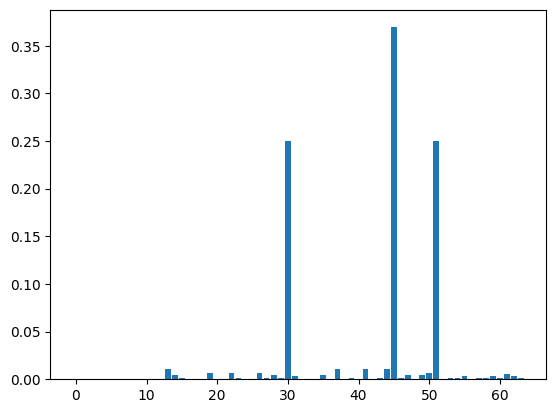

In [43]:
plt.bar(range(len(probs)), probs)
plt.show()

In [44]:
# Resposta
# Converter para binário com n dígitos
format(posicao, f'0{n}b')

'101101'

# [5 Conclusões](#secao6)

Os resultados devem ser testados em detrimento dos pesos utilizados, tais como `M1`, `M2`, `dt` e `gates`. Além disso, a construção do circuito quântico do TSP com FALQON e sua execução em um computador quântico serão tratados como trabalhos futuros.